# Airport Network Analysis — Basic Network Analysis

This notebook describes the size, connectivity, hub airports, and degree distribution of the global airport-route network.

In [2]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path('../src').resolve()))
from graph_builder import build_graph, network_summary

G = build_graph('../Data')
summary = network_summary(G, top_n=10)

## 1. Network-level metrics

In [3]:
metrics = pd.Series({
    'Airports (nodes)': summary['nodes'],
    'Routes (edges)': summary['edges'],
    'Network density': round(summary['density'], 6),
    'Weak components': summary['weakly_connected_components'],
    'Largest weak component': summary['largest_weak_component_size'],
    'Route reciprocity': round(summary['reciprocity'], 4),
})
metrics.to_frame('value')

,value
Airports (nodes),3214.000000
Routes (edges),36907.000000
Network density,0.003574
Weak components,7.000000
Largest weak component,3188.000000
Route reciprocity,0.978000


### Interprettion

The airport network consists of **3,214 airports** connected by **36,907 direct flight routes**, forming a large but sparse transportation network.

The network density is very low (0.003574), indicating that only a small fraction of all possible airport-to-airport connections actually exist. This is expected because airlines operate routes selectively based on passenger demand, geography, and economic feasibility rather than connecting every airport directly.

The presence of only **7 weakly connected components**, with the largest containing **3,188 airports**, shows that nearly the entire global airport system forms one giant connected transportation network.

Furthermore, the high route reciprocity (0.9780) indicates that most flight routes operate in both directions, reflecting the bidirectional nature of commercial air transportation.

## 2. Hub airports

Total degree counts inbound and outbound unique route connections. Airports with high degree function as hubs in the network.

In [7]:
top_airports = pd.DataFrame(summary['top_airports'])
top_airports.index = top_airports.index + 1
top_airports

,airport_id,name,city,country,degree,in_degree,out_degree
1,340,Frankfurt am Main Airport,Frankfurt,Germany,477,238,239
2,1382,Charles de Gaulle International Airport,Paris,France,470,233,237
3,580,Amsterdam Airport Schiphol,Amsterdam,Netherlands,463,231,232
4,1701,Atatürk International Airport,Istanbul,Turkey,451,227,224
5,3682,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,433,216,217
6,3830,Chicago O'Hare International Airport,Chicago,United States,409,203,206
7,3364,Beijing Capital International Airport,Beijing,China,408,204,204
8,346,Munich Airport,Munich,Germany,380,189,191
9,4029,Domodedovo International Airport,Moscow,Russia,375,188,187
10,3670,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,372,185,187


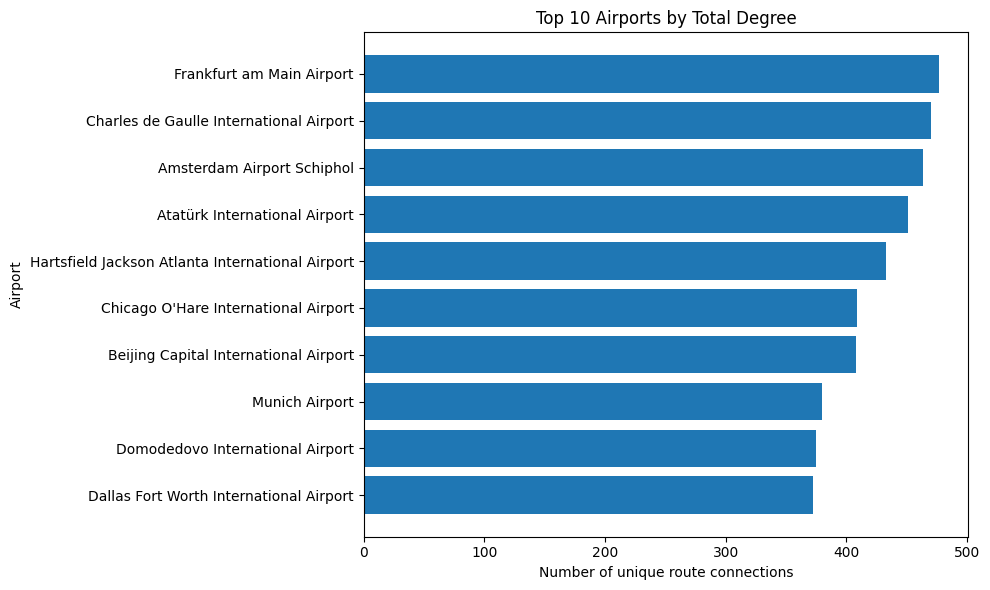

In [8]:
plot_data = top_airports.sort_values('degree')
labels = plot_data['name'] + ' (' + plot_data['iata'].fillna('') + ')' if 'iata' in plot_data else plot_data['name']

plt.figure(figsize=(10, 6))
plt.barh(plot_data['name'], plot_data['degree'], color='#1f77b4')
plt.title('Top 10 Airports by Total Degree')
plt.xlabel('Number of unique route connections')
plt.ylabel('Airport')
plt.tight_layout()
plt.show()

### Interpretation

The degree ranking confirms that a relatively small number of airports dominate the global route network. Airports such as Frankfurt, Charles de Gaulle, Amsterdam Schiphol, and Atatürk International Airport maintain hundreds of direct route connections, making them major transportation hubs.

These airports play a central role in facilitating international passenger movement and airline connectivity. Their exceptionally high degree values suggest that disruptions affecting these hubs are likely to have a much greater impact on the network than failures at smaller regional airports.

This observation motivates the more detailed centrality analysis presented in the next notebook, where additional measures beyond degree are used to identify structurally important airports.

## 3. Degree distribution

A long-tailed distribution indicates that most airports have relatively few direct connections, while a small number serve as highly connected hubs.

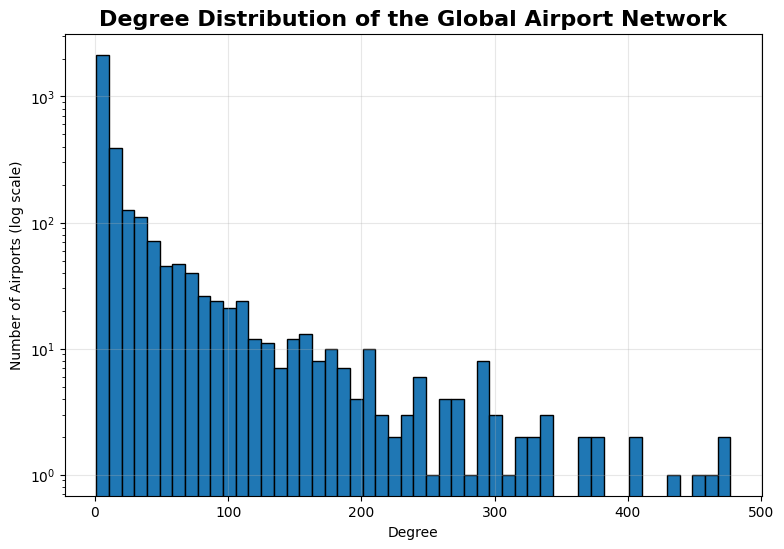

In [9]:
import matplotlib.pyplot as plt

degrees = [degree for node, degree in G.degree()]

plt.figure(figsize=(9, 6))

plt.hist(
    degrees,
    bins=50,
    edgecolor="black"
)

plt.xlabel("Degree")
plt.ylabel("Number of Airports (log scale)")
plt.title(
    "Degree Distribution of the Global Airport Network",
    fontsize=16,
    weight="bold"
)
plt.yscale("log")
plt.grid(alpha=0.3)

plt.savefig(
    "../Reports/figures/degree_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The degree distribution is highly right-skewed, with most airports having relatively few direct connections and only a small number of airports acting as highly connected hubs.

The logarithmic scale highlights this long-tailed behaviour more clearly by making low-frequency, high-degree airports visible. Such distributions are commonly observed in real-world transportation and infrastructure networks.

This imbalance in connectivity suggests that the airport network is dominated by a few major hubs, a structural property that motivates the centrality and resilience analyses performed in the subsequent notebooks.

## Conclusion

The basic network statistics reveal that the global airport transportation network is a large, sparse, and highly connected system dominated by a small number of major hub airports.

The network-level metrics, hub rankings, and degree distribution together indicate that connectivity is distributed unevenly across airports, with a few highly connected hubs supporting a substantial portion of global air transportation.

These fundamental structural characteristics provide the basis for the more advanced analyses presented in the following notebooks, including centrality analysis, geographic visualization, community detection, and network resilience under airport failures.